In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
path = "ne_10m_rivers_lake_centerlines.shp"
df = gpd.read_file(path)
df

,dissolve,scalerank,featurecla,name,name_alt,rivernum,note,min_zoom,name_en,min_label,...,name_sv,name_tr,name_vi,name_zh,name_fa,name_he,name_uk,name_ur,name_zht,geometry
0,975River,9,River,None,None,975,None,7.1,None,8.1,...,None,None,None,None,None,None,None,None,None,"LINESTRING (22.75649 -20.47161, 22.79458 -20.4..."
1,976River,9,River,Rungwa,None,976,None,7.1,Rungwa,8.1,...,Rungwa,Rungwa,Sông Rungwa,伦瓜河,رونگوا,רונגווה,Рунгва,رنگوا,倫瓜河,"MULTILINESTRING ((32 -7.24993, 32.02793 -7.238..."
2,977River,9,River,Ligonha,None,977,None,7.1,Ligonha,8.1,...,Ligonha,Ligonha,Sông Ligonha,利戈尼亚河,لیگونها,ליגונה,Лігонха,لیگونہا,利戈尼亞河,"MULTILINESTRING ((39.12783 -16.86663, 39.12598..."
3,978River,9,River,Dongwe,None,978,None,7.1,Dongwe,8.1,...,Dongwe,Dongwe,Sông Dongwe,松威河,دونگوه,דונגווה,Донгве,ڈانگوے,東威河,"LINESTRING (25.5333 -14.58333, 25.49502 -14.59..."
4,979River,9,River,Cuito,None,979,None,7.1,Cuito,8.1,...,Cuito,Cuito,Sông Cuito,奎托河,کیتو,קיטו,Куіто,کیوٹو,奎托河,"MULTILINESTRING ((20.75 -17.99993, 20.75234 -1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1468,8River,1,River,Missouri,None,8,None,2.0,Missouri,3.0,...,Missourifloden,Missouri,Missouri,密蘇里河,رودخانه میزوری,מיזורי,Міссурі,دریائے مسوری,密蘇里河,"MULTILINESTRING ((-108.1906 47.60175, -108.249..."
1469,22561Salinas,10,River,Salinas,None,22561,Version 1.2 edit in N. America and Europe,7.2,Salinas,8.2,...,Salinas River,Salinas,Sông Salinas,萨利纳斯河,سالیناس,סאלינאס,Салінас,سالیناس,萨利纳斯河,"LINESTRING (-120.88884 36.00002, -120.85425 35..."
1470,1121River,9,River,Rio Batepito,None,1121,None,7.1,Batevito,8.1,...,Rio Batepito,Rio Batepito,Sông Rio Batepito,巴特皮托河,ریو باتپیتو,ריו באטיפו,Ріо-Батепіто,ریو باٹیپیٹو,巴特皮托河,"LINESTRING (-109.19028 31.57971, -109.20256 31..."
1471,21320Lake Centerline,11,Lake Centerline,None,None,21320,ID is link back to CEC data,6.7,None,7.7,...,None,None,None,None,None,None,None,None,None,"MULTILINESTRING ((-106.83016 62.51925, -106.86..."


In [5]:
df_dup = df.duplicated()
df_dup.sum()

0

In [4]:
df.columns = df.columns.str.strip()
df.columns

Index(['dissolve', 'scalerank', 'featurecla', 'name', 'name_alt', 'rivernum',
       'note', 'min_zoom', 'name_en', 'min_label', 'ne_id', 'label',
       'wikidataid', 'name_ar', 'name_bn', 'name_de', 'name_es', 'name_fr',
       'name_el', 'name_hi', 'name_hu', 'name_id', 'name_it', 'name_ja',
       'name_ko', 'name_nl', 'name_pl', 'name_pt', 'name_ru', 'name_sv',
       'name_tr', 'name_vi', 'name_zh', 'name_fa', 'name_he', 'name_uk',
       'name_ur', 'name_zht', 'geometry'],
      dtype='object')

In [6]:
cols_to_drop = ['name_ar', 'name_bn', 'name_de', 'name_es',
       'name_fr', 'name_el', 'name_hi', 'name_hu', 'name_id', 'name_it',
       'name_ja', 'name_ko', 'name_nl', 'name_pl', 'name_pt', 'name_ru',
       'name_sv', 'name_tr', 'name_vi', 'name_zh', 'ne_id', 'name_fa',
       'name_he', 'name_uk', 'name_ur', 'name_zht']
df = df.drop(columns=cols_to_drop)
df

,dissolve,scalerank,featurecla,name,name_alt,rivernum,note,min_zoom,name_en,min_label,label,wikidataid,geometry
0,975River,9,River,None,None,975,None,7.1,None,8.1,None,None,"LINESTRING (22.75649 -20.47161, 22.79458 -20.4..."
1,976River,9,River,Rungwa,None,976,None,7.1,Rungwa,8.1,Rungwa,Q35311383,"MULTILINESTRING ((32 -7.24993, 32.02793 -7.238..."
2,977River,9,River,Ligonha,None,977,None,7.1,Ligonha,8.1,Ligonha,None,"MULTILINESTRING ((39.12783 -16.86663, 39.12598..."
3,978River,9,River,Dongwe,None,978,None,7.1,Dongwe,8.1,Dongwe,None,"LINESTRING (25.5333 -14.58333, 25.49502 -14.59..."
4,979River,9,River,Cuito,None,979,None,7.1,Cuito,8.1,Cuito,Q1143331,"MULTILINESTRING ((20.75 -17.99993, 20.75234 -1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1468,8River,1,River,Missouri,None,8,None,2.0,Missouri,3.0,Missouri,Q5419,"MULTILINESTRING ((-108.1906 47.60175, -108.249..."
1469,22561Salinas,10,River,Salinas,None,22561,Version 1.2 edit in N. America and Europe,7.2,Salinas,8.2,Salinas,Q1161673,"LINESTRING (-120.88884 36.00002, -120.85425 35..."
1470,1121River,9,River,Rio Batepito,None,1121,None,7.1,Batevito,8.1,Batepito,Q27149993,"LINESTRING (-109.19028 31.57971, -109.20256 31..."
1471,21320Lake Centerline,11,Lake Centerline,None,None,21320,ID is link back to CEC data,6.7,None,7.7,None,None,"MULTILINESTRING ((-106.83016 62.51925, -106.86..."


In [8]:
df.isnull().sum()

dissolve         0
scalerank        0
featurecla       0
name            86
name_alt      1414
rivernum         0
note          1433
min_zoom         0
name_en         86
min_label        0
label           86
wikidataid     183
geometry         0
dtype: int64

In [9]:
df['note'].unique()

array([None, 'Version 1.2 edit in N. America and Europe',
       'Changed in 2.0', 'Changed in 4.0', 'Version 1.3',
       'linework edited 20121205', 'ID is link back to CEC data'],
      dtype=object)

In [13]:
df['label'].unique()

array([None, 'Rungwa', 'Ligonha', ..., 'Madison', 'Missouri', 'Batepito'],
      dtype=object)

<Axes: >

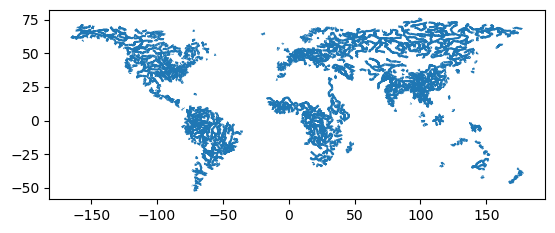

In [14]:
gdf = gpd.GeoDataFrame(df, geometry='geometry')

gdf.plot()

In [15]:
import os

folder = "/Users/chih-hsingchu/Desktop/uiuc dsc/team-nuclear-family/data/usgs_hydrography/ne_10m_rivers_lake_centerlines"

print(os.listdir(folder))

['ne_10m_rivers_lake_centerlines.shx', 'ne_10m_rivers_lake_centerlines.cpg', 'ne_10m_rivers_lake_centerlines.shp', 'ne_110m_admin_0_countries.dbf copy', 'ne_110m_admin_0_countries.shx copy', 'ne_110m_admin_0_countries.VERSION copy.txt', 'ne_110m_admin_0_countries.cpg copy', 'ne_10m_rivers_lake_centerlines.dbf', 'ne_10m_rivers_lake_centerlines.VERSION.txt', 'ne_10m_rivers_lake_centerlines.prj', 'ne_110m_admin_0_countries.shp copy', 'river_cleansed.ipynb', 'ne_110m_admin_0_countries.prj copy', 'ne_110m_admin_0_countries.README copy.html', 'ne_10m_rivers_lake_centerlines.README.html']


In [20]:
shapefile_path = "/Users/chih-hsingchu/Desktop/uiuc dsc/team-nuclear-family/data/usgs_hydrography/ne_10m_lakes/ne_110m_admin_0_countries.shp"
world = gpd.read_file(shapefile_path)
us = world[world['ADMIN'] == "United States of America"]
from shapely import wkt



# Make it a GeoDataFrame
df = gpd.GeoDataFrame(df, geometry='geometry')
df = df.set_crs(us.crs)

us_rivers = gpd.sjoin(df, us, how='inner', predicate='intersects')

us_rivers


,dissolve,scalerank_left,featurecla_left,name,name_alt,rivernum,note,min_zoom,name_en,min_label,...,FCLASS_VN,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA
1115,974River,0,Lake Centerline,Santee,None,974,None,7.0,Santee,8.0,...,None,None,None,None,None,None,None,None,None,None
1116,988River,9,River,Salinas,None,988,None,7.1,Salinas,8.1,...,None,None,None,None,None,None,None,None,None,None
1117,989River,9,River,None,None,989,None,7.1,None,8.1,...,None,None,None,None,None,None,None,None,None,None
1120,1008River,9,River,Sagavanirktok,None,1008,None,7.1,Sagavanirktok,8.1,...,None,None,None,None,None,None,None,None,None,None
1121,1009River,9,River,Meade,None,1009,None,7.1,Meade,8.1,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1466,7River,1,River,Madison,None,7,None,2.0,Madison,3.0,...,None,None,None,None,None,None,None,None,None,None
1467,8Lake Centerline,1,Lake Centerline,Missouri,None,8,None,2.0,Missouri,3.0,...,None,None,None,None,None,None,None,None,None,None
1468,8River,1,River,Missouri,None,8,None,2.0,Missouri,3.0,...,None,None,None,None,None,None,None,None,None,None
1469,22561Salinas,10,River,Salinas,None,22561,Version 1.2 edit in N. America and Europe,7.2,Salinas,8.2,...,None,None,None,None,None,None,None,None,None,None


In [30]:
world.columns

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)

In [22]:
us_rivers.columns

Index(['dissolve', 'scalerank_left', 'featurecla_left', 'name', 'name_alt',
       'rivernum', 'note', 'min_zoom', 'name_en', 'min_label',
       ...
       'FCLASS_VN', 'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR',
       'FCLASS_IT', 'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA'],
      dtype='object', length=182)

In [23]:
us_rivers.rename(columns={"featurecla_left": "featurecla", "scalerank_left": "scalerank"}, inplace=True)

In [29]:
us_rivers.columns.to_list()

['dissolve',
 'scalerank',
 'featurecla',
 'name',
 'name_alt',
 'rivernum',
 'note',
 'min_zoom',
 'name_en',
 'min_label',
 'label',
 'wikidataid',
 'geometry',
 'index_right',
 'featurecla_right',
 'scalerank_right',
 'LABELRANK',
 'SOVEREIGNT',
 'SOV_A3',
 'ADM0_DIF',
 'LEVEL',
 'TYPE',
 'TLC',
 'ADMIN',
 'ADM0_A3',
 'GEOU_DIF',
 'GEOUNIT',
 'GU_A3',
 'SU_DIF',
 'SUBUNIT',
 'SU_A3',
 'BRK_DIFF',
 'NAME',
 'NAME_LONG',
 'BRK_A3',
 'BRK_NAME',
 'BRK_GROUP',
 'ABBREV',
 'POSTAL',
 'FORMAL_EN',
 'FORMAL_FR',
 'NAME_CIAWF',
 'NOTE_ADM0',
 'NOTE_BRK',
 'NAME_SORT',
 'NAME_ALT',
 'MAPCOLOR7',
 'MAPCOLOR8',
 'MAPCOLOR9',
 'MAPCOLOR13',
 'POP_EST',
 'POP_RANK',
 'POP_YEAR',
 'GDP_MD',
 'GDP_YEAR',
 'ECONOMY',
 'INCOME_GRP',
 'FIPS_10',
 'ISO_A2',
 'ISO_A2_EH',
 'ISO_A3',
 'ISO_A3_EH',
 'ISO_N3',
 'ISO_N3_EH',
 'UN_A3',
 'WB_A2',
 'WB_A3',
 'WOE_ID',
 'WOE_ID_EH',
 'WOE_NOTE',
 'ADM0_ISO',
 'ADM0_DIFF',
 'ADM0_TLC',
 'ADM0_A3_US',
 'ADM0_A3_FR',
 'ADM0_A3_RU',
 'ADM0_A3_ES',
 'ADM0_A3_CN',
 

In [31]:
us_rivers = us_rivers[df.columns]
us_rivers

,dissolve,scalerank,featurecla,name,name_alt,rivernum,note,min_zoom,name_en,min_label,label,wikidataid,geometry
1115,974River,0,Lake Centerline,Santee,None,974,None,7.0,Santee,8.0,Santee,Q2223479,"MULTILINESTRING ((-80.23644 33.46247, -80.1650..."
1116,988River,9,River,Salinas,None,988,None,7.1,Salinas,8.1,Salinas,Q1161673,"LINESTRING (-120.88892 36.00002, -120.9104 36...."
1117,989River,9,River,None,None,989,None,7.1,None,8.1,None,None,"LINESTRING (-119.43345 39.87287, -119.41899 39..."
1120,1008River,9,River,Sagavanirktok,None,1008,None,7.1,Sagavanirktok,8.1,Sagavanirktok,Q1569192,"LINESTRING (-148.90898 68.18073, -148.87671 68..."
1121,1009River,9,River,Meade,None,1009,None,7.1,Meade,8.1,Meade,Q2412334,"LINESTRING (-158.48247 69.27004, -158.48108 69..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1466,7River,1,River,Madison,None,7,None,2.0,Madison,3.0,Madison,Q947477,"MULTILINESTRING ((-111.09849 44.75934, -111.08..."
1467,8Lake Centerline,1,Lake Centerline,Missouri,None,8,None,2.0,Missouri,3.0,Missouri,Q5419,"MULTILINESTRING ((-111.69731 46.66157, -111.68..."
1468,8River,1,River,Missouri,None,8,None,2.0,Missouri,3.0,Missouri,Q5419,"MULTILINESTRING ((-108.1906 47.60175, -108.249..."
1469,22561Salinas,10,River,Salinas,None,22561,Version 1.2 edit in N. America and Europe,7.2,Salinas,8.2,Salinas,Q1161673,"LINESTRING (-120.88884 36.00002, -120.85425 35..."


In [32]:
us_rivers.columns

Index(['dissolve', 'scalerank', 'featurecla', 'name', 'name_alt', 'rivernum',
       'note', 'min_zoom', 'name_en', 'min_label', 'label', 'wikidataid',
       'geometry'],
      dtype='object')

In [33]:
df.columns

Index(['dissolve', 'scalerank', 'featurecla', 'name', 'name_alt', 'rivernum',
       'note', 'min_zoom', 'name_en', 'min_label', 'label', 'wikidataid',
       'geometry'],
      dtype='object')

In [34]:
df = us_rivers

In [35]:
df

,dissolve,scalerank,featurecla,name,name_alt,rivernum,note,min_zoom,name_en,min_label,label,wikidataid,geometry
1115,974River,0,Lake Centerline,Santee,None,974,None,7.0,Santee,8.0,Santee,Q2223479,"MULTILINESTRING ((-80.23644 33.46247, -80.1650..."
1116,988River,9,River,Salinas,None,988,None,7.1,Salinas,8.1,Salinas,Q1161673,"LINESTRING (-120.88892 36.00002, -120.9104 36...."
1117,989River,9,River,None,None,989,None,7.1,None,8.1,None,None,"LINESTRING (-119.43345 39.87287, -119.41899 39..."
1120,1008River,9,River,Sagavanirktok,None,1008,None,7.1,Sagavanirktok,8.1,Sagavanirktok,Q1569192,"LINESTRING (-148.90898 68.18073, -148.87671 68..."
1121,1009River,9,River,Meade,None,1009,None,7.1,Meade,8.1,Meade,Q2412334,"LINESTRING (-158.48247 69.27004, -158.48108 69..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1466,7River,1,River,Madison,None,7,None,2.0,Madison,3.0,Madison,Q947477,"MULTILINESTRING ((-111.09849 44.75934, -111.08..."
1467,8Lake Centerline,1,Lake Centerline,Missouri,None,8,None,2.0,Missouri,3.0,Missouri,Q5419,"MULTILINESTRING ((-111.69731 46.66157, -111.68..."
1468,8River,1,River,Missouri,None,8,None,2.0,Missouri,3.0,Missouri,Q5419,"MULTILINESTRING ((-108.1906 47.60175, -108.249..."
1469,22561Salinas,10,River,Salinas,None,22561,Version 1.2 edit in N. America and Europe,7.2,Salinas,8.2,Salinas,Q1161673,"LINESTRING (-120.88884 36.00002, -120.85425 35..."
